Matriz de Vandermonde:
[[1 0 0]
 [1 1 1]
 [1 2 4]]

Coeficientes del polinomio:
[ 1.   3.5 -1.5]


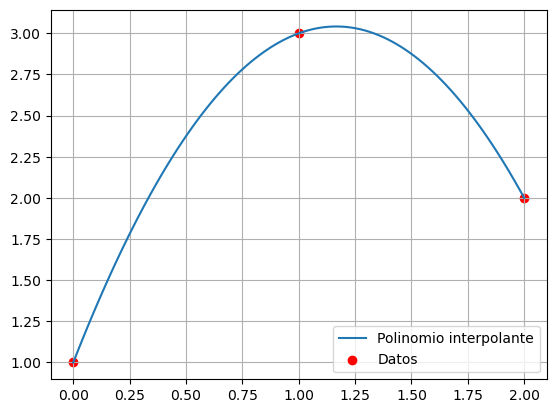

In [1]:

#COMENTE CADA LINEA A LA DERECHA
import numpy as np
import matplotlib.pyplot as plt

# Datos conocidos
x = np.array([0, 1, 2])
y = np.array([1, 3, 2])

# Construir la matriz de Vandermonde
X = np.vander(x, N=3, increasing=True)

# Resolver el sistema Xa = y
a = np.linalg.solve(X, y)

print("Matriz de Vandermonde:")
print(X)

print("\nCoeficientes del polinomio:")
print(a)

# Evaluar el polinomio
xx = np.linspace(0, 2, 100)
#COMPLETE: --------------------

# Graficar
plt.plot(xx, p, label="Polinomio interpolante")
plt.scatter(x, y, color="red", label="Datos")
plt.grid()
plt.legend()
plt.show()

Número de puntos: 19
Grado del polinomio: 18
Condición matriz Vandermonde: 9.55875357037179e+19
Condición matriz Newton: 733089109.5550698
Error máximo base canónica: 7.58417217689572e-05
Error máximo Lagrange: 7.647505082047923e-05
Error máximo Newton: 7.647506272957794e-05


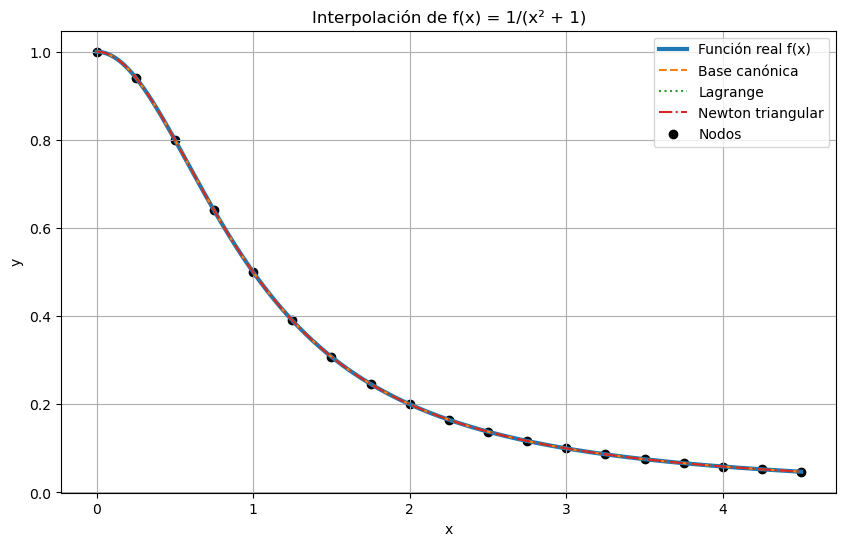

In [1]:
import numpy as np                                      # Importa NumPy para cálculos numéricos
import matplotlib.pyplot as plt                         # Importa Matplotlib para graficar

def f(x):                                               # Define la función original
    return 1 / (x**2 + 1)                               # Retorna f(x) = 1/(x^2+1)

#COMPLETAR EN CLASE

# =====================================================
# 1. INTERPOLACIÓN EN BASE CANÓNICA
# =====================================================

V = np.vander(x_nodes, N, increasing=True)              # Construye la matriz de Vandermonde

cond_V = np.linalg.cond(V, 1)                           # Calcula el número de condición de Vandermonde

coef_can = np.linalg.solve(V, y_nodes)                  # Resuelve el sistema Vc = y

def P_canonica(x):                                      # Define el polinomio en base canónica
    suma = 0                                            # Inicializa la suma
    for k in range(N):                                  # Recorre los coeficientes
        suma += coef_can[k] * x**k                     # Suma c_k x^k
    return suma                                         # Retorna el valor del polinomio

y_can = P_canonica(x_plot)                              # Evalúa el polinomio canónico

# =====================================================
# 2. INTERPOLACIÓN EN FORMA DE LAGRANGE
# =====================================================

#complete en clase

# =====================================================
# 3. INTERPOLACIÓN DE NEWTON CON SISTEMA TRIANGULAR
# =====================================================

A_newton = np.zeros((N, N))                              # Crea la matriz triangular inferior de Newton

for i in range(N):                                      # Recorre las filas de la matriz
    A_newton[i, 0] = 1                                  # La primera columna es p_0(x_i)=1
    for k in range(1, i + 1):                           # Recorre columnas hasta la diagonal
        producto = 1                                    # Inicializa el producto p_k(x_i)
        for j in range(k):                              # Calcula el producto desde j=0 hasta k-1
            producto *= x_nodes[i] - x_nodes[j]         # Multiplica por (x_i - x_j)
        A_newton[i, k] = producto                       # Guarda p_k(x_i) en la matriz

coef_newton = np.linalg.solve(A_newton, y_nodes)        # Resuelve A_newton c = y

def P_newton(x):                                        # Define el polinomio de Newton
    suma = coef_newton[0]                               # Inicia con c_0
    for k in range(1, N):                               # Recorre desde k=1 hasta n
        producto = 1                                    # Inicializa p_k(x)
        for j in range(k):                              # Calcula producto hasta k-1
            producto *= x - x_nodes[j]                  # Multiplica por (x - x_j)
        suma += coef_newton[k] * producto              # Suma c_k p_k(x)
    return suma                                         # Retorna P(x)

y_new = P_newton(x_plot)                                # Evalúa el polinomio de Newton

# =====================================================
# 4. ERRORES
# =====================================================

#COMPLETE EN CLASE

print("Número de puntos:", N)                           # Imprime el número de puntos
print("Grado del polinomio:", n)                        # Imprime el grado del polinomio
print("Condición matriz Vandermonde:", cond_V)          # Imprime condición de Vandermonde
print("Condición matriz Newton:", cond_newton)          # Imprime condición matriz Newton
print("Error máximo base canónica:", error_can)         # Imprime error canónico
print("Error máximo Lagrange:", error_lag)              # Imprime error Lagrange
print("Error máximo Newton:", error_new)                # Imprime error Newton

# =====================================================
# 5. GRÁFICA COMPARATIVA
# =====================================================

plt.figure(figsize=(10, 6))                             # Crea la figura

plt.plot(x_plot, y_real, label="Función real f(x)", linewidth=3)       # Grafica la función real
plt.plot(x_plot, y_can, "--", label="Base canónica")                  # Grafica forma canónica
plt.plot(x_plot, y_lag, ":", label="Lagrange")                        # Grafica forma de Lagrange
plt.plot(x_plot, y_new, "-.", label="Newton triangular")              # Grafica forma de Newton
plt.scatter(x_nodes, y_nodes, color="black", label="Nodos")           # Grafica los nodos

plt.title("Interpolación de f(x) = 1/(x² + 1)")         # Título
plt.xlabel("x")                                         # Etiqueta eje x
plt.ylabel("y")                                         # Etiqueta eje y
plt.grid(True)                                          # Activa la grilla
plt.legend()                                            # Muestra leyenda
plt.show()                                              # Muestra la gráfica

In [6]:
print(x_nodes)

[0.   0.18 0.36 0.54 0.72 0.9  1.08 1.26 1.44 1.62 1.8  1.98 2.16 2.34
 2.52 2.7  2.88 3.06 3.24 3.42 3.6  3.78 3.96 4.14 4.32 4.5 ]
